<a href="https://colab.research.google.com/github/amandavalenca-creator/Trabalho_final_ci-ncia_de_dados/blob/main/C%C3%B3pia_de_Trabalho_final_de_ci%C3%AAncia_de_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/phyton trabalho/Teen_Mental_Health_Dataset.csv")

In [ ]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


##### Questão 1: Qual é a faixa etária com maior índice de uso de redes sociais? Além disso, considerando apenas esse grupo específico, qual plataforma apresenta maior popularidade: Instagram ou TikTok?


In [ ]:
media_horas_por_idade = df.groupby('age')['daily_social_media_hours'].mean()
idade_maior_uso = media_horas_por_idade.idxmax()
horas_maior_uso = media_horas_por_idade.max()

In [ ]:
print(f"1. A idade com maior uso médio de redes sociais é {idade_maior_uso} anos (Média: {horas_maior_uso:.2f} horas/dia).")

1. A idade com maior uso médio de redes sociais é 17 anos (Média: 4.76 horas/dia).


In [ ]:
df_idade_especifica = df[df['age'] == idade_maior_uso]

In [ ]:
plataformas_contagem = df_idade_especifica['platform_usage'].value_counts()

print(f"\n2. Preferência de plataforma entre os jovens de {idade_maior_uso} anos:")
print(plataformas_contagem)


2. Preferência de plataforma entre os jovens de 17 anos:
platform_usage
Instagram    62
TikTok       54
Both         54
Name: count, dtype: int64


In [ ]:
insta_count = plataformas_contagem.get('Instagram', 0)
tiktok_count = plataformas_contagem.get('TikTok', 0)

if insta_count > tiktok_count:
    print("\nConclusão: O Instagram é mais popular que o TikTok nesse grupo específico.")
elif tiktok_count > insta_count:
    print("\nConclusão: O TikTok é mais popular que o Instagram nesse grupo específico.")
else:
    print("\nConclusão: Instagram e TikTok possuem exatamente a mesma popularidade nesse grupo.")


Conclusão: O Instagram é mais popular que o TikTok nesse grupo específico.


Adolescentes de 17 anos costumam usar com mais frequência o Instagram e por mais tempo do que o adequado gerando problemas como comparações sociais, por estarem entrando na fase adulta costumam achar que estão ficando para trás.

#####Questão 2: Qual a média de depressão e ansiedade das pessoas que tem maior nível de dependência em telas?

In [ ]:
maior_dependencia = df['addiction_level'].max()

In [ ]:
df_maior_dependencia = df[df['addiction_level'] == maior_dependencia]

In [ ]:
media_ansiedade = df_maior_dependencia['anxiety_level'].mean()

In [ ]:
taxa_depressao = df_maior_dependencia['depression_label'].mean() * 100
print(f"Resultados para o grupo com nível de dependência máximo ({maior_dependencia})")
print(f" Média de Ansiedade (anxiety_level): {media_ansiedade:.2f}")
print(f" Incidência de Depressão: {taxa_depressao:.2f}% dos jovens neste grupo possuem depressão.")

Resultados para o grupo com nível de dependência máximo (10)
 Média de Ansiedade (anxiety_level): 5.79
 Incidência de Depressão: 4.35% dos jovens neste grupo possuem depressão.


isso mostra um número elevado em relação a incidência de transtornos mentais que tem relação direta com alta média de dependência por telas.

##### Questão 3: O impacto das redes sociais (nível de stress,performace academica, atividades físicas e horas de sono) afeta qual gênero em maior quantidade?

In [ ]:
impacto_total = {}

In [ ]:
for genero in df['gender'].unique():
    df_genero = df[df['gender'] == genero]

In [ ]:
correlacoes = df_genero[['daily_social_media_hours', 'stress_level', 'academic_performance', 'physical_activity', 'sleep_hours']].corr()

In [ ]:
impacto = correlacoes['daily_social_media_hours'].drop('daily_social_media_hours')

In [ ]:
impacto_total[genero] = impacto.abs().sum()

In [ ]:
genero_mais_impactado = max(impacto_total, key=impacto_total.get)
maior_valor = impacto_total[genero_mais_impactado]
print(f"De acordo com a tabela, o gênero mais impactado é: {genero_mais_impactado}")
print(f"Soma total das correlações (nível de impacto): {maior_valor:.2f}")

De acordo com a tabela, o gênero mais impactado é: female
Soma total das correlações (nível de impacto): 0.16


As mulheres sentem mais os efeitos negativos do uso excessivo das redes, por serem mais vulneráveis e terem mais sensibilidades a rejeições sociais. Além disso, possuem uma pressão estética maior.

##### Questão 4: Qual plataforma as pessoas usam mais antes de dormir?

In [ ]:
tempo_medio_antes_dormir = df.groupby('platform_usage')['screen_time_before_sleep'].mean()

In [ ]:
plataforma_campea = tempo_medio_antes_dormir.idxmax()
maior_tempo = tempo_medio_antes_dormir.max()

In [ ]:
 for plataforma, tempo in tempo_medio_antes_dormir.items():
    print(f"{plataforma}: {tempo:.2f} horas")

Both: 1.75 horas
Instagram: 1.71 horas
TikTok: 1.76 horas


In [ ]:
print(f"\nConclusão: A plataforma mais usada antes de dormir é o {plataforma_campea}, com uma média de {maior_tempo:.2f} horas.")


Conclusão: A plataforma mais usada antes de dormir é o TikTok, com uma média de 1.76 horas.


O uso do tiktok antes de dormir atrapalha diretamente a qualidade do sono, por fazer as pessoas perderem a noção de tempo, e a liberação de dopamina.

##### Questão 5: Qual a média de sono das pessoas que mais e menos utilizam as redes sociais antes de dormir?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
max_tempo_tela = df['screen_time_before_sleep'].max()
min_tempo_tela = df['screen_time_before_sleep'].min()
grupo_mais_usa = df[df['screen_time_before_sleep'] == max_tempo_tela]
grupo_menos_usa = df[df['screen_time_before_sleep'] == min_tempo_tela]

In [ ]:
media_sono_mais_usa = grupo_mais_usa['sleep_hours'].mean()
media_sono_menos_usa = grupo_menos_usa['sleep_hours'].mean()

In [ ]:
print("--- Relação entre Uso de Telas antes de Dormir e Horas de Sono ---")
print(f"Maior uso ({max_tempo_tela}h de tela): dorme em média {media_sono_mais_usa:.2f} horas.")
print(f"Menor uso ({min_tempo_tela}h de tela): dorme em média {media_sono_menos_usa:.2f} horas.\n")

--- Relação entre Uso de Telas antes de Dormir e Horas de Sono ---
Maior uso (3.0h de tela): dorme em média 6.68 horas.
Menor uso (0.5h de tela): dorme em média 6.12 horas.



In [ ]:
categorias = ['MAIS usam antes de dormir', 'MENOS usam antes de dormir']
medias_sono = [media_sono_mais_usa, media_sono_menos_usa]
cores = ['#d9534f', '#5cb85c']

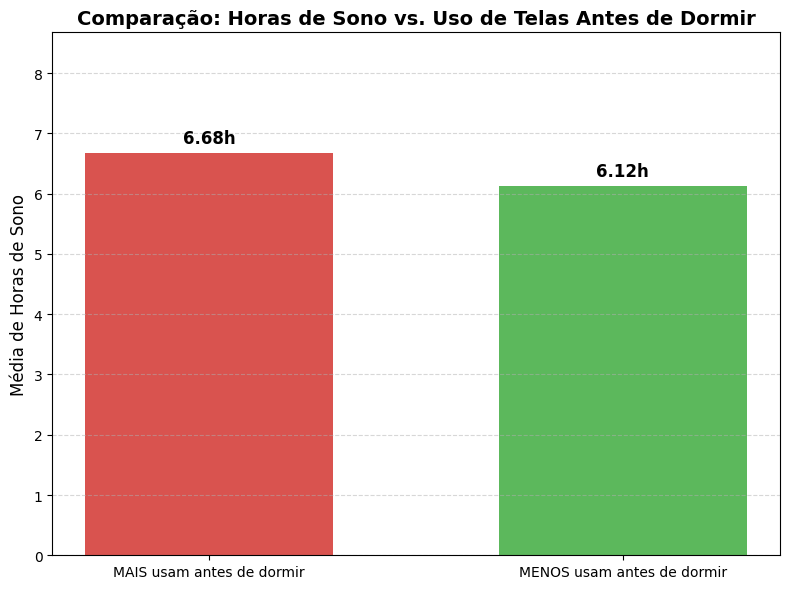

In [ ]:
plt.figure(figsize=(8, 6))
barras = plt.bar(categorias, medias_sono, color=cores, width=0.6)
plt.title('Comparação: Horas de Sono vs. Uso de Telas Antes de Dormir', fontsize=14, fontweight='bold')
plt.ylabel('Média de Horas de Sono', fontsize=12)
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura + 0.1,
             f'{altura:.2f}h', ha='center', va='bottom', fontsize=12, fontweight='bold')
    plt.ylim(0, max(medias_sono) + 2) # Dá um espaço extra no topo para o número não cortar
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Pode parecer contradiório, porém as pessoas com mais uso de tela são as que mais tem tempo de sono, mas não significa que são a com mais qualidades. Isso ocorre pela carga execessiva de tela gerando um cansaço mental mais forte.

#####Questão 6: Qual o nivel de atividade fisica das pessoas que mais utilizam redes sociais?

In [ ]:
max_horas_redes = df['daily_social_media_hours'].max()

In [ ]:
grupo_mais_usa_redes = df[df['daily_social_media_hours'] == max_horas_redes]

In [ ]:
media_atividade_fisica = grupo_mais_usa_redes['physical_activity'].mean()

In [ ]:
print("Atividade Física das Pessoas que MAIS Usam Redes Sociais ")
print(f" Maior tempo de uso diário registrado na base: {max_horas_redes} horas.")
print(f" Média de atividade física desse grupo: {media_atividade_fisica:.2f}")

Atividade Física das Pessoas que MAIS Usam Redes Sociais 
 Maior tempo de uso diário registrado na base: 8.0 horas.
 Média de atividade física desse grupo: 1.17


Quanto mais as pessoas ficam nas telas , menos vontade tem de praticar atividades. A famosa armadilha da dopamina barata, que significa que as pessoas conseguem prazer mais fácil mexendo na tela do que se esforçando fisicamente

#####Questão 7: Qual a média de interação social por idade?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
mapa_interacao = {'low': 1, 'medium': 2, 'high': 3}
df['social_interaction_numeric'] = df['social_interaction_level'].map(mapa_interacao)

In [ ]:
media_interacao_idade = df.groupby('age')['social_interaction_numeric'].mean()

In [ ]:
idade_mais_interacao = media_interacao_idade.idxmax()
idade_menos_interacao = media_interacao_idade.idxmin()

valor_max = media_interacao_idade.max()
valor_min = media_interacao_idade.min()

In [ ]:
print("--- Nível de Interação Social por Faixa Etária ---")
print(f"Idade com MAIOR interação social: {idade_mais_interacao} anos (Média: {valor_max:.2f})")
print(f"Idade com MENOR interação social: {idade_menos_interacao} anos (Média: {valor_min:.2f})\n")

--- Nível de Interação Social por Faixa Etária ---
Idade com MAIOR interação social: 19 anos (Média: 2.04)
Idade com MENOR interação social: 18 anos (Média: 1.89)



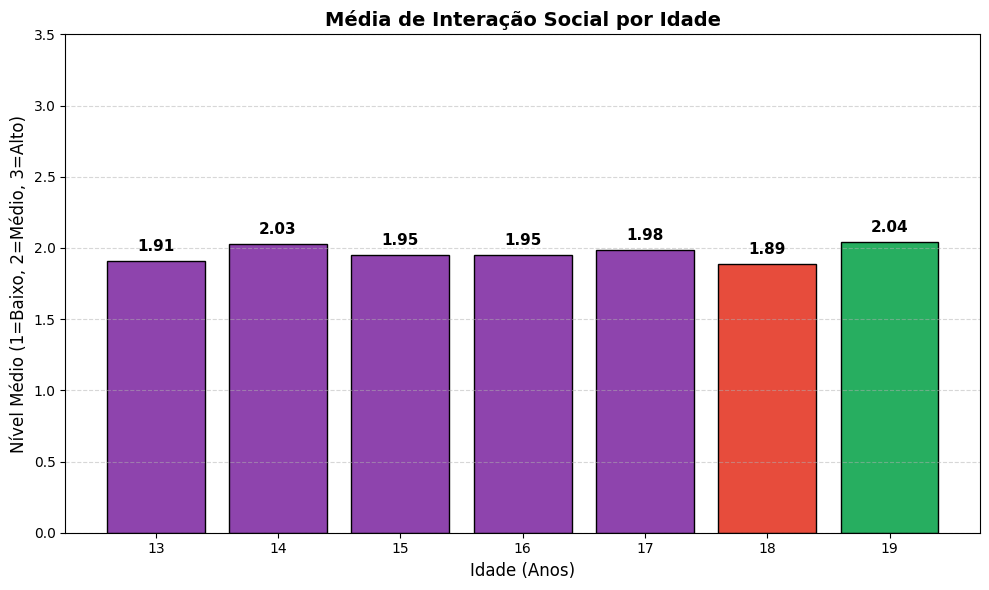

In [ ]:
plt.figure(figsize=(10, 6))
barras = plt.bar(media_interacao_idade.index, media_interacao_idade.values, color='#8E44AD', edgecolor='black')
for i, idade in enumerate(media_interacao_idade.index):
    if idade == idade_mais_interacao:
        barras[i].set_color('#27AE60')
        barras[i].set_edgecolor('black')
    elif idade == idade_menos_interacao:
        barras[i].set_color('#E74C3C')
        barras[i].set_edgecolor('black')
        plt.title('Média de Interação Social por Idade', fontsize=14, fontweight='bold')
plt.xlabel('Idade (Anos)', fontsize=12)
plt.ylabel('Nível Médio (1=Baixo, 2=Médio, 3=Alto)', fontsize=12)
plt.xticks(media_interacao_idade.index)
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura + 0.05,
             f'{altura:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    plt.ylim(0, 3.5)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Adolescentes mais novos usam as telas quase exclusivamente para entretenimento e fofocas, enquanto os mais velhos que estão entrando na vida adulta, utilizam para construir suas identidades e interagir mais.

#####Questão 8: Qual o tempo de tela das pessoas que tem o nivel de estresse acima de 7?

In [ ]:
df_alto_estresse = df[df['stress_level'] > 7]

In [ ]:
media_horas_diarias = df_alto_estresse['daily_social_media_hours'].mean()
media_tela_antes_dormir = df_alto_estresse['screen_time_before_sleep'].mean()

In [ ]:
print("Tempo de Tela (Estresse acima de 7)")
print(f" Média de tempo diário nas redes sociais: {media_horas_diarias:.2f} horas")
print(f" Média de tempo de tela antes de dormir: {media_tela_antes_dormir:.2f} horas")

Tempo de Tela (Estresse acima de 7)
 Média de tempo diário nas redes sociais: 4.69 horas
 Média de tempo de tela antes de dormir: 1.74 horas


O uso de tela e o aumento do estresse é uma resposta biológica. O nosso cérebro sabota nossa tranquilidade com o passar do tempo de telas. Isso gera um efeito de tempo perdido, que no final do dia da a impressão que o tempo voo e não rendeu nada, criando uma ansiedade extrema.